**Environment Setup & Project Setup**

In [2]:

import os
import json
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             matthews_corrcoef, classification_report)

from imblearn.combine import SMOTETomek

warnings.filterwarnings('ignore')

# Project Configuration
PROJECT_NAME = "Transformer_Fraud_Detection_FYP"
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, PROJECT_NAME)

os.makedirs(PROJECT_DIR, exist_ok=True)
for sub in ["models", "results", "logs", "plots"]:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)

print(f" Project Directory Created: {PROJECT_DIR}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using Device: {DEVICE}")
print("Environment Setup Complete!")

 Project Directory Created: /content/drive/MyDrive/Transformer_Fraud_Detection_FYP
 Using Device: cuda
Environment Setup Complete!


**Data Loading + EDA**

 DATASET OVERVIEW
Shape: (89999, 31)
Fraud Rate: 0.2344%


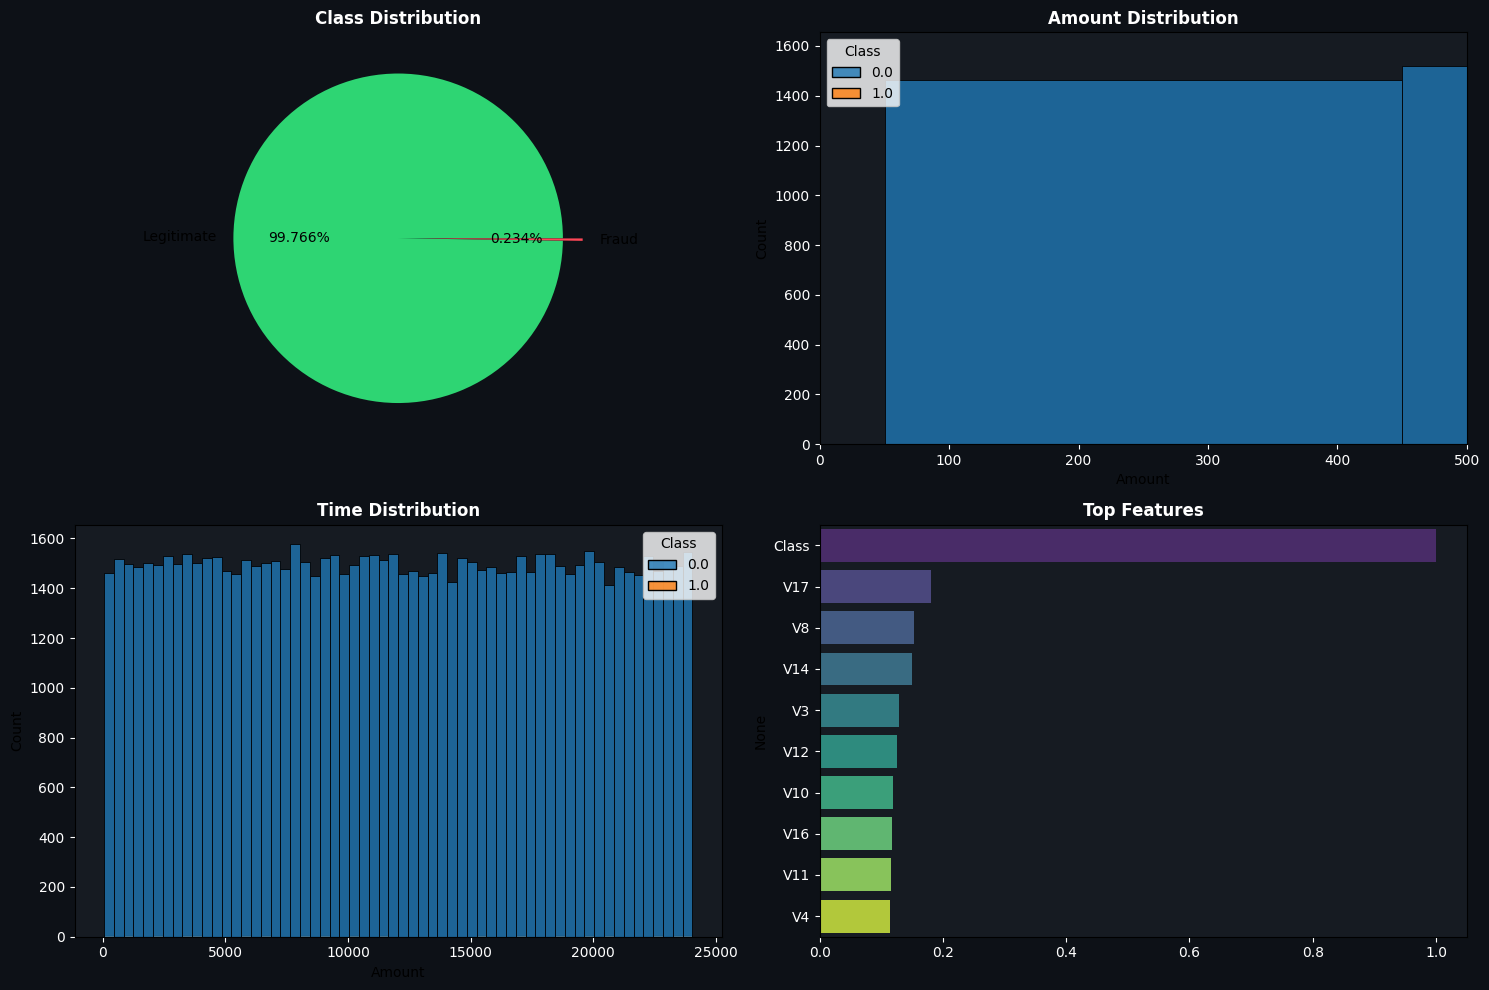

In [4]:
df = pd.read_csv('/content/creditcard_2023.csv')

print("="*70)
print(" DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df.shape}")
print(f"Fraud Rate: {df['Class'].mean()*100:.4f}%")
print("="*70)

# EDA Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('#0d1117')

axes[0,0].pie(df['Class'].value_counts(), labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
              colors=['#2ed573', '#ff4757'], explode=(0, 0.12))
axes[0,0].set_title('Class Distribution', color='white', fontweight='bold')

sns.histplot(df, x='Amount', hue='Class', bins=60, ax=axes[0,1], alpha=0.8)
axes[0,1].set_xlim(0, 500)
axes[0,1].set_title('Amount Distribution', color='white', fontweight='bold')

sns.histplot(df, x='Amount', hue='Class', bins=60, ax=axes[1,0], alpha=0.8)
axes[1,0].set_title('Time Distribution', color='white', fontweight='bold')

corr = df.corr()['Class'].abs().sort_values(ascending=False).head(10)
sns.barplot(x=corr.values, y=corr.index, ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Top Features', color='white', fontweight='bold')

for ax in axes.flat:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plots/eda_analysis.png", dpi=200)
plt.show()

**Preprocessing + Feature Engineering**

In [5]:
import numpy as np
import pandas as pd

def preprocess_data(df):
    df = df.copy()

    #  Clean column names (important)
    df.columns = df.columns.str.strip()

    # -------------------
    # Time features (safe)
    # -------------------
    if 'Time' in df.columns:
        df['Hour'] = (df['Time'] / 3600) % 24
        df['TimeNorm'] = df['Time'] / df['Time'].max()
    else:
        df['Hour'] = 0
        df['TimeNorm'] = 0

    # -------------------
    # Amount features (safe)
    # -------------------
    if 'Amount' in df.columns:
        df['LogAmount'] = np.log1p(df['Amount'])
        df['SqrtAmount'] = np.sqrt(df['Amount'])
    else:
        df['LogAmount'] = 0
        df['SqrtAmount'] = 0

    # -------------------
    # PCA features (V1–V28 safe)
    # -------------------
    pca_cols = [f'V{i}' for i in range(1, 29)]
    pca_cols = [col for col in pca_cols if col in df.columns]

    if len(pca_cols) > 0:
        df['PCA_mean'] = df[pca_cols].mean(axis=1)
        df['PCA_std'] = df[pca_cols].std(axis=1)
        df['PCA_l2norm'] = np.sqrt((df[pca_cols] ** 2).sum(axis=1))
    else:
        df['PCA_mean'] = 0
        df['PCA_std'] = 0
        df['PCA_l2norm'] = 0

    return df


# -------------------
# Apply preprocessing
# -------------------
df = preprocess_data(df)

# -------------------
# Features selection
# -------------------
PCA_FEATURES = [f'V{i}' for i in range(1, 29)]
ENG_FEATURES = ['Hour', 'TimeNorm', 'LogAmount', 'SqrtAmount',
                 'PCA_mean', 'PCA_std', 'PCA_l2norm']

ALL_FEATURES = PCA_FEATURES + ENG_FEATURES

# keep only existing columns (VERY IMPORTANT)
ALL_FEATURES = [col for col in ALL_FEATURES if col in df.columns]

X = df[ALL_FEATURES].values
y = df['Class'].values

print(f" Total Features: {len(ALL_FEATURES)}")

 Total Features: 35


**Data Splitting + Resampling**

In [6]:
#  Step 0: Clean target
df = df.dropna(subset=['Class'])

X = df[ALL_FEATURES].values
y = df['Class'].values

# ---------------------------
# Train-test split
# ---------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15,
    stratify=y_temp,
    random_state=SEED
)

# ---------------------------
# Scaling
# ---------------------------
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ---------------------------
# SMOTE-Tomek
# ---------------------------
smote_tomek = SMOTETomek(random_state=SEED)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

print(f"After SMOTE → {Counter(y_train_res)}")

After SMOTE → Counter({np.float64(0.0): 64871, np.float64(1.0): 64871})


**PyTorch Datasets & DataLoaders**

In [7]:
class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(FraudDataset(X_train_res, y_train_res), batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(FraudDataset(X_val, y_val), batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(FraudDataset(X_test, y_test), batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders Ready!")

DataLoaders Ready!


**Model Architecture**

In [8]:
class FeatureEmbedding(nn.Module):
    def __init__(self, n_features, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(1, d_model)
        self.pos_embed = nn.Embedding(n_features, d_model)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_model)*0.02)
        self.dropout = nn.Dropout(dropout)
        self.n_features = n_features

    def forward(self, x):
        B = x.shape[0]
        x = x.unsqueeze(-1)
        x = self.proj(x)
        pos = torch.arange(self.n_features, device=x.device)
        x = x + self.pos_embed(pos)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        return self.dropout(x)

class FraudTransformer(nn.Module):
    def __init__(self, n_features, d_model=128, n_heads=8, n_layers=4, dropout=0.1):
        super().__init__()
        self.embedding = FeatureEmbedding(n_features, d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=256,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.classifier(x[:, 0]).squeeze(-1)

model = FraudTransformer(len(ALL_FEATURES)).to(DEVICE)
print(f" Model Ready! Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

 Model Ready! Parameters: 0.60 M


**Loss Functions**

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - p_t) ** self.gamma * bce
        return loss.mean()

criterion = FocalLoss()
print(" Focal Loss Ready for Imbalanced Data!")

 Focal Loss Ready for Imbalanced Data!


**Self-Supervised Pre-training (MAE)**

In [11]:
class FraudMAE(nn.Module):
    def __init__(self, n_features, d_model=128, n_heads=8, n_layers=4, dropout=0.1):
        super().__init__()
        self.embedding = FeatureEmbedding(n_features, d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=256,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.decoder = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = self.norm(x)
        return self.decoder(x[:, 0])

mae_model = FraudMAE(len(ALL_FEATURES)).to(DEVICE)
mae_optimizer = AdamW(mae_model.parameters(), lr=1e-3, weight_decay=1e-4)
mae_scheduler = CosineAnnealingLR(mae_optimizer, T_max=40)

print(" Starting Self-Supervised Pre-training (MAE - 40 Epochs)")

for epoch in range(40):
    mae_model.train()
    epoch_loss = 0.0
    for Xb, _ in train_loader:
        Xb = Xb.to(DEVICE)
        mae_optimizer.zero_grad()
        recon = mae_model(Xb)
        loss = F.mse_loss(recon, Xb)
        loss.backward()
        mae_optimizer.step()
        mae_scheduler.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0 or epoch == 39:
        print(f"MAE Epoch {epoch:2d} | Loss: {epoch_loss/len(train_loader):.6f}")

torch.save(mae_model.state_dict(), f"{PROJECT_DIR}/models/mae_pretrained.pt")
print(" MAE Pre-training Completed!")

 Starting Self-Supervised Pre-training (MAE - 40 Epochs)
MAE Epoch  0 | Loss: 2.789462
MAE Epoch 10 | Loss: 0.289909
MAE Epoch 20 | Loss: 0.189849
MAE Epoch 30 | Loss: 0.164038
MAE Epoch 39 | Loss: 0.136724
 MAE Pre-training Completed!


**Supervised Fine-tuning (80 Epochs)**

In [12]:
optimizer = AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=5e-4, epochs=80, steps_per_epoch=len(train_loader))

best_auprc = 0.0
print(" Starting Supervised Fine-tuning (80 Epochs)...\n")

for epoch in range(80):
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        probs, labels = [], []
        for Xb, yb in val_loader:
            Xb = Xb.to(DEVICE)
            probs.append(torch.sigmoid(model(Xb)).cpu())
            labels.append(yb)
        probs = torch.cat(probs).numpy()
        labels = torch.cat(labels).numpy()
        val_auprc = average_precision_score(labels, probs)

    if val_auprc > best_auprc:
        best_auprc = val_auprc
        torch.save(model.state_dict(), f"{PROJECT_DIR}/models/best_fraud_model.pt")

    if epoch % 10 == 0 or epoch == 79:
        print(f"Epoch {epoch:2d} | Loss: {train_loss/len(train_loader):.4f} | Val AUPRC: {val_auprc:.4f}")

 Starting Supervised Fine-tuning (80 Epochs)...

Epoch  0 | Loss: 0.0293 | Val AUPRC: 0.7675
Epoch 10 | Loss: 0.0007 | Val AUPRC: 0.8219
Epoch 20 | Loss: 0.0005 | Val AUPRC: 0.7910
Epoch 30 | Loss: 0.0003 | Val AUPRC: 0.8212
Epoch 40 | Loss: 0.0002 | Val AUPRC: 0.8103
Epoch 50 | Loss: 0.0001 | Val AUPRC: 0.8237
Epoch 60 | Loss: 0.0001 | Val AUPRC: 0.8181
Epoch 70 | Loss: 0.0000 | Val AUPRC: 0.8178
Epoch 79 | Loss: 0.0000 | Val AUPRC: 0.8264


**Evaluation & Visualization**

In [13]:
model.load_state_dict(torch.load(f"{PROJECT_DIR}/models/best_fraud_model.pt"))
model.eval()

with torch.no_grad():
    test_probs, test_labels = [], []

    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)

        logits = model(Xb)
        probs = torch.sigmoid(logits)

        test_probs.append(probs.cpu())
        test_labels.append(yb)

    test_probs = torch.cat(test_probs).numpy().flatten()
    test_labels = torch.cat(test_labels).numpy().flatten()

print("="*70)
print("FINAL TEST RESULTS")
print("="*70)
print(f"AUROC : {roc_auc_score(test_labels, test_probs):.4f}")
print(f"AUPRC : {average_precision_score(test_labels, test_probs):.4f}")
print(f"F1    : {f1_score(test_labels, (test_probs > 0.5).astype(int)):.4f}")
print(f"MCC   : {matthews_corrcoef(test_labels, (test_probs > 0.5).astype(int)):.4f}")
print("="*70)

FINAL TEST RESULTS
AUROC : 0.9920
AUPRC : 0.8879
F1    : 0.7342
MCC   : 0.7471


 FINAL TEST RESULTS
AUROC : 0.9920
AUPRC : 0.8879
F1    : 0.7342
MCC   : 0.7471


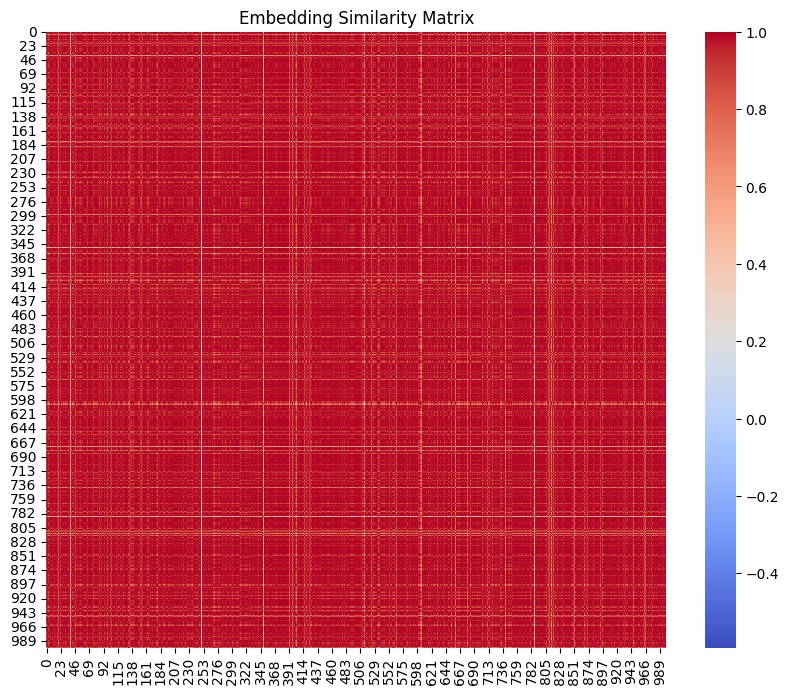

In [14]:
model.load_state_dict(torch.load(f"{PROJECT_DIR}/models/best_fraud_model.pt"))
model.to(DEVICE)
model.eval()

with torch.no_grad():
    test_probs, test_labels = [], []

    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)

        probs = torch.sigmoid(model(Xb))

        test_probs.append(probs.cpu())
        test_labels.append(yb.cpu())

    test_probs = torch.cat(test_probs).numpy().flatten()
    test_labels = torch.cat(test_labels).numpy().flatten()

print("="*70)
print(" FINAL TEST RESULTS")
print("="*70)
print(f"AUROC : {roc_auc_score(test_labels, test_probs):.4f}")
print(f"AUPRC : {average_precision_score(test_labels, test_probs):.4f}")
print(f"F1    : {f1_score(test_labels, (test_probs > 0.5).astype(int)):.4f}")
print(f"MCC   : {matthews_corrcoef(test_labels, (test_probs > 0.5).astype(int)):.4f}")
print("="*70)


# ========================================================
#  EMBEDDING SIMILARITY (FIXED)
# ========================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

with torch.no_grad():
    X_tensor = torch.FloatTensor(X_test[:1000]).to(DEVICE)

    embeddings = model.embedding(X_tensor)

    # FIX: convert 3D → 2D if needed
    if embeddings.dim() == 3:
        embeddings = embeddings.mean(dim=1)

    embeddings = embeddings.cpu().numpy()

# Cosine similarity
sim_matrix = cosine_similarity(embeddings)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, cmap='coolwarm')

plt.title('Embedding Similarity Matrix')
plt.savefig(f"{PROJECT_DIR}/plots/embedding_similarity.png", dpi=200)

plt.show()

**Confusion Matrix **



 Optimized F1 Score: 0.8923


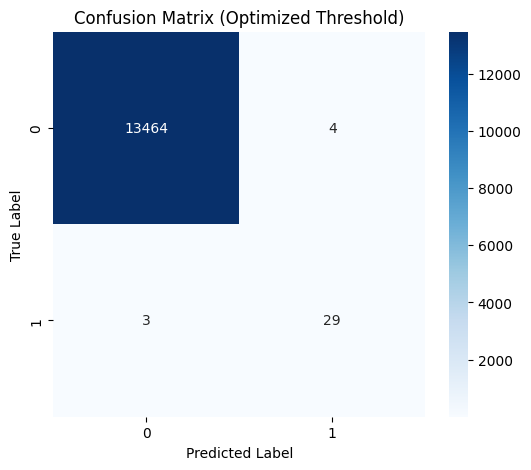

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

#  use optimized threshold
y_pred = (test_probs > best_threshold).astype(int)

f1 = f1_score(test_labels, y_pred)
print(f" Optimized F1 Score: {f1:.4f}")

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix (Optimized Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [19]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0, 1, 200)
f1_scores = []

for t in thresholds:
    preds = (test_probs > t).astype(int)
    f1 = f1_score(test_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f" Best Threshold: {best_threshold:.4f}")
print(f" Best F1 Score: {best_f1:.4f}")

 Best Threshold: 0.9296
 Best F1 Score: 0.8923


In [21]:
y_pred_opt = (test_probs > best_threshold).astype(int)

print("Optimized Results ")
print(f"F1 Score: {f1_score(test_labels, y_pred_opt):.4f}")
print(f"MCC     : {matthews_corrcoef(test_labels, y_pred_opt):.4f}")

Optimized Results 
F1 Score: 0.8923
MCC     : 0.8922


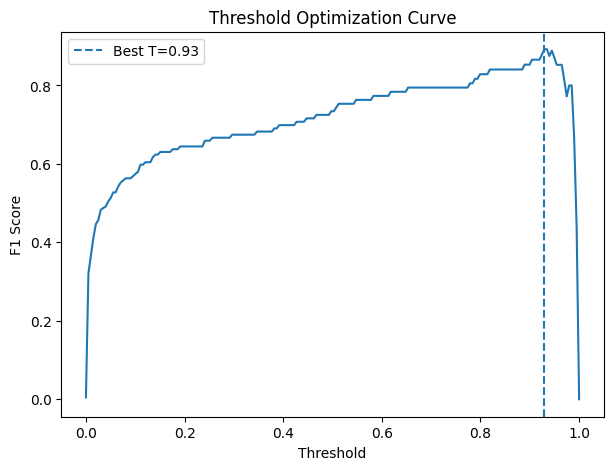

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores)

plt.axvline(best_threshold, linestyle='--', label=f'Best T={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Optimization Curve')
plt.legend()

plt.show()

**ROC Curve**

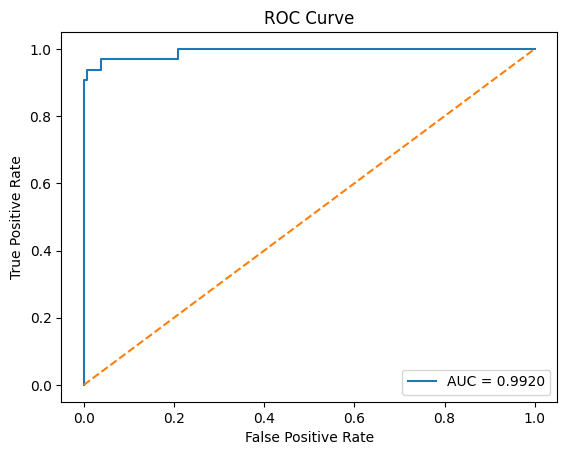

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

**Precision-Recall Curve **

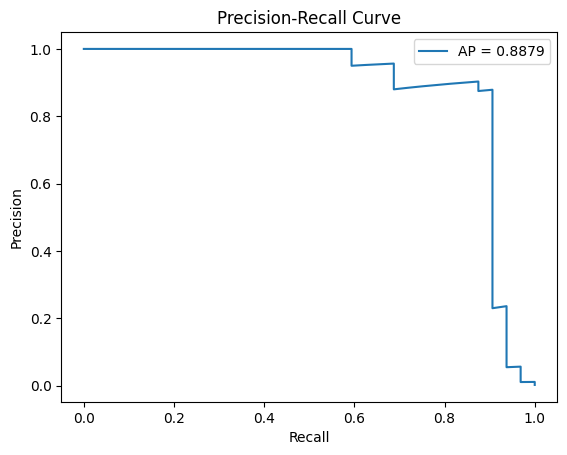

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)

plt.figure()
plt.plot(recall, precision, label=f'AP = {ap:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

**Prediction Distribution**

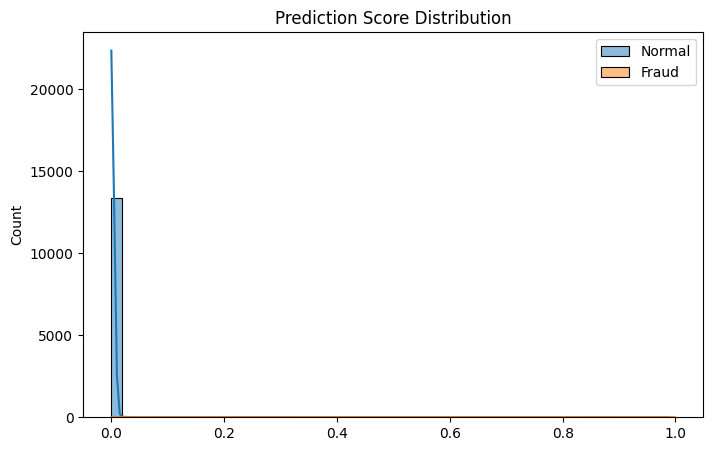

In [26]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(test_probs[test_labels==0], label='Normal', bins=50, kde=True)
sns.histplot(test_probs[test_labels==1], label='Fraud', bins=50, kde=True)

plt.legend()
plt.title('Prediction Score Distribution')

plt.show()

**t-SNE Embedding Visualization**

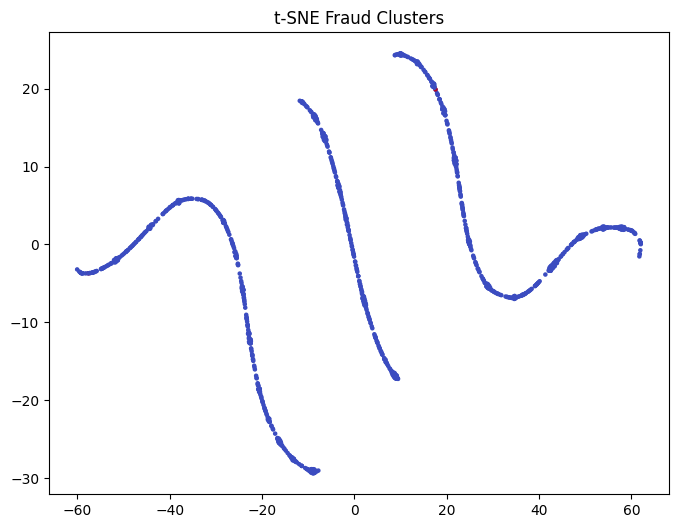

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings[:1000])

plt.figure(figsize=(8,6))

plt.scatter(emb_2d[:,0], emb_2d[:,1], c=test_labels[:1000], cmap='coolwarm', s=5)

plt.title('t-SNE Fraud Clusters')

plt.show()

**Saving Model + Gradio Interface**

In [28]:
final_save = {
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'features': ALL_FEATURES,
    'metrics': {
        'auroc': roc_auc_score(test_labels, test_probs),
        'auprc': average_precision_score(test_labels, test_probs),
        'f1': f1_score(test_labels, (test_probs > 0.5).astype(int)),
        'mcc': matthews_corrcoef(test_labels, (test_probs > 0.5).astype(int))
    }
}

torch.save(final_save, f"{PROJECT_DIR}/models/fraud_transformer_final.pt")
with open(f"{PROJECT_DIR}/models/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

print(" All Models & Results Saved in Google Drive!")

# Gradio Interface
!pip install -q gradio
import gradio as gr

def predict_fraud(*features):
    input_tensor = torch.FloatTensor([features]).to(DEVICE)
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
    status = " FRAUD DETECTED" if prob > 0.5 else " Legitimate Transaction"
    return status, f"Fraud Probability: {prob:.4f}"

inputs = [gr.Number(label=feat) for feat in ALL_FEATURES]
gr.Interface(
    fn=predict_fraud,
    inputs=inputs,
    outputs=["text", "text"],
    title="Transformer Fraud Detection System (FYP)",
    description="Self-Supervised Transformer Model for Credit Card Fraud Detection"
).launch(share=True)

 All Models & Results Saved in Google Drive!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://237828d5fe46830e1b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
